# Phase 4: Performance & Risk Analytics Notebook
This notebook consumes the `scripts.risk_metrics` library to calculate financial returns, volatility, risk-adjusted ratios, benchmark sensitivities, and portfolio concentration metrics.

In [1]:
import sys

import seaborn as sns
from IPython.display import Image, display

sys.path.append('../scripts')

from risk_metrics import compute_all_scheme_risk_metrics, save_risk_metrics_to_db

sns.set_theme(style='whitegrid')
print('Risk Analytics Environment Initialized.')

Risk Analytics Environment Initialized.


## 1. Scheme Risk Metrics Overview
Computing quantitative risk metrics across all mutual fund schemes using `scripts/risk_metrics.py`.

In [2]:
df_metrics = compute_all_scheme_risk_metrics('../mutual_fund_analytics.db')
save_risk_metrics_to_db(df_metrics, '../mutual_fund_analytics.db')
display(df_metrics[['amfi_code', 'scheme_name', 'category', 'cagr_pct', 'volatility_ann_pct', 'sharpe_ratio', 'sortino_ratio', 'alpha', 'beta', 'hhi']].head(10))

[2026-07-29 22:49:42] [INFO] [risk_metrics] Computing risk metrics across all schemes using DB: ../mutual_fund_analytics.db


[2026-07-29 22:49:42] [INFO] [risk_metrics] Successfully computed risk metrics for 40 schemes.


[2026-07-29 22:49:42] [INFO] [risk_metrics] Saving risk metrics to SQLite database table `fact_risk_metrics`...


[2026-07-29 22:49:42] [INFO] [risk_metrics] Successfully persisted risk metrics to database.


,amfi_code,scheme_name,category,cagr_pct,volatility_ann_pct,sharpe_ratio,sortino_ratio,alpha,beta,hhi
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,2.64,12.30,-0.27,-0.39,-9.36,1.0,1395.34
1,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,4.46,3.30,-0.47,-0.65,-7.54,1.0,850.00
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,30.12,16.02,1.51,2.25,18.12,1.0,1475.92
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,23.54,12.33,1.42,2.15,11.54,1.0,1293.32
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,7.94,21.81,0.09,0.13,-4.06,1.0,2007.00
5,101208,ABSL Liquid Fund - Regular - Growth,Debt,6.51,0.46,1.10,1.43,-5.49,1.0,850.00
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,Equity,18.23,10.86,1.13,1.68,6.23,1.0,1747.09
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,1.17,15.33,-0.32,-0.44,-10.83,1.0,1146.93
8,102887,UTI Flexi Cap Fund - Regular - Growth,Equity,16.84,13.33,0.81,1.21,4.84,1.0,1298.05
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,24.05,11.97,1.51,2.25,12.05,1.0,1682.98


## 2. Risk-Return Scatter & Rolling Dynamics
Evaluating return per unit of volatility, rolling Sharpe ratios, and rolling returns over time.

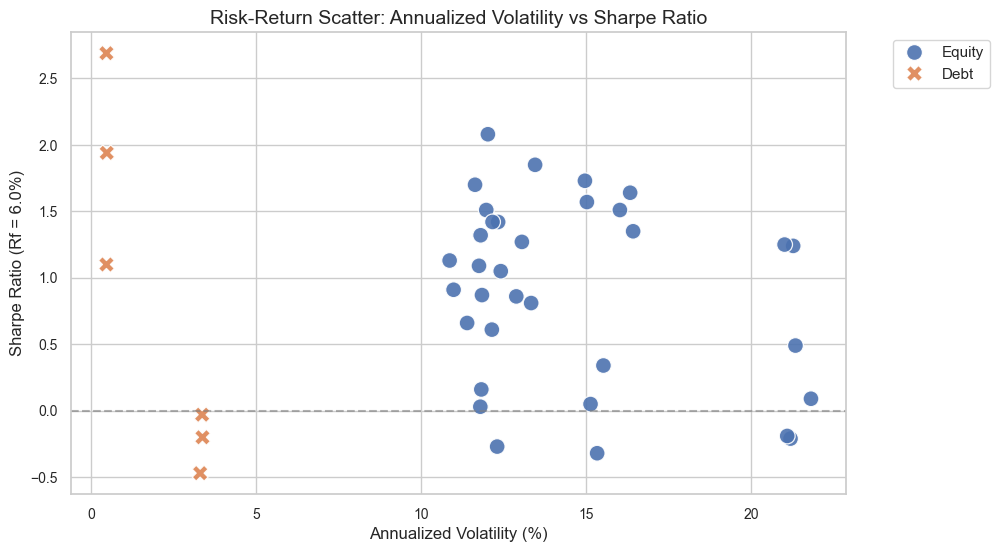

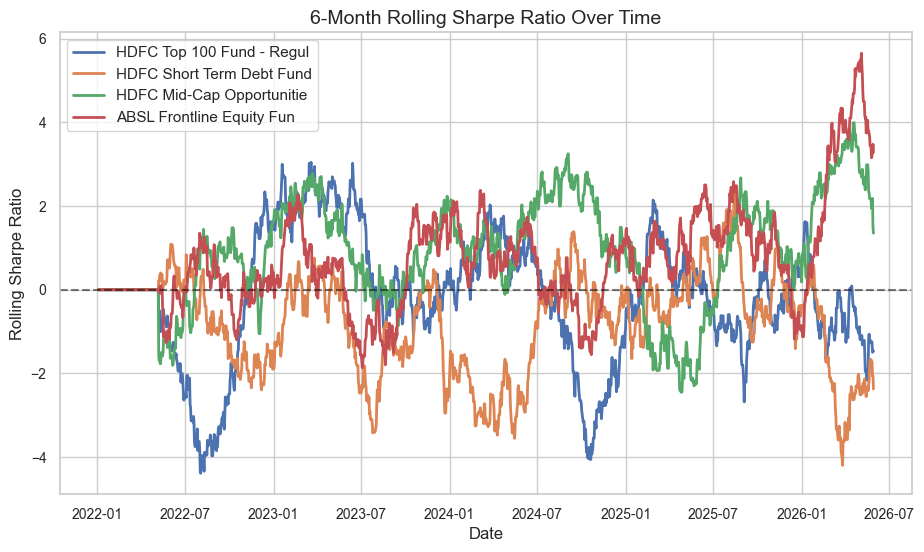

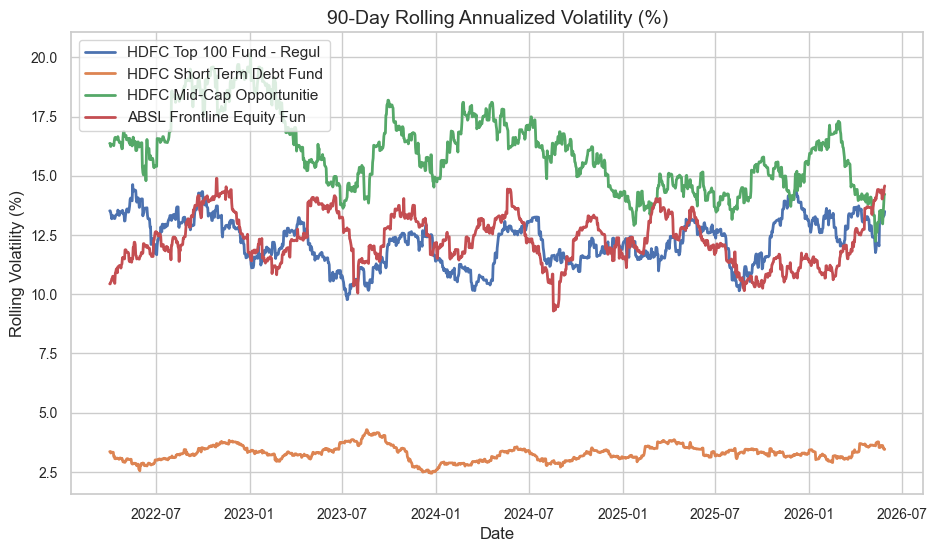

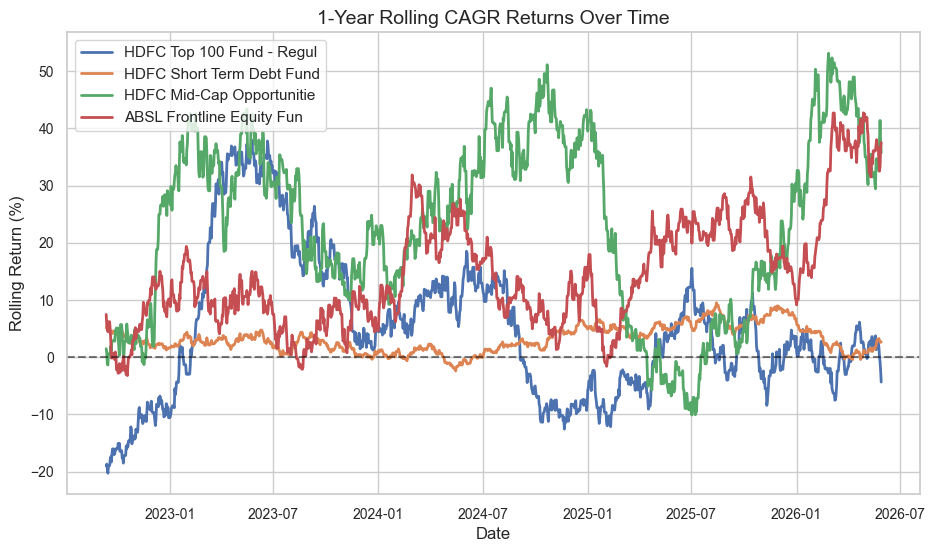

In [3]:
display(Image(filename='../figures/risk_metrics/01_risk_return_scatter.png'))
display(Image(filename='../figures/risk_metrics/02_rolling_sharpe.png'))
display(Image(filename='../figures/risk_metrics/03_rolling_volatility.png'))
display(Image(filename='../figures/risk_metrics/04_rolling_returns.png'))

## 3. Drawdown Curve & Duration Analysis
Analyzing underwater peak-to-trough drops and drawdown durations across scheme categories.

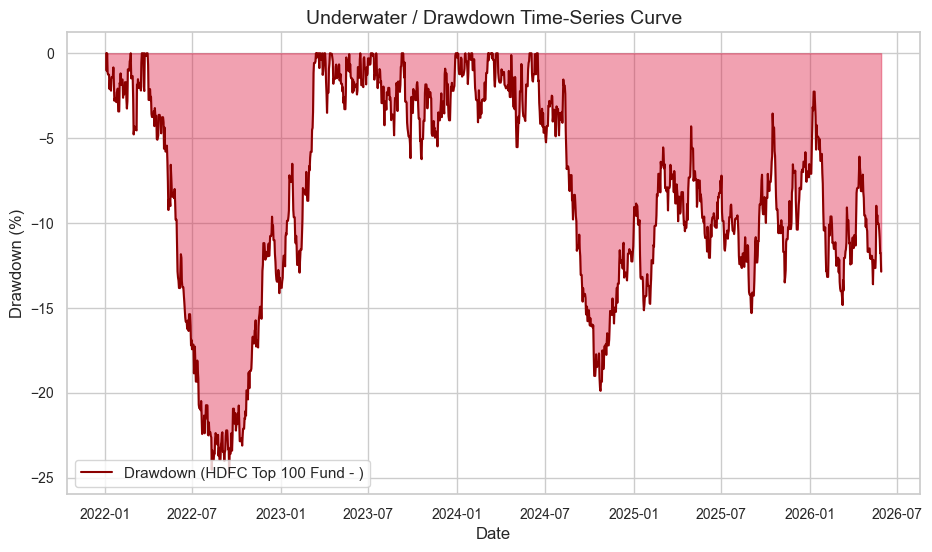

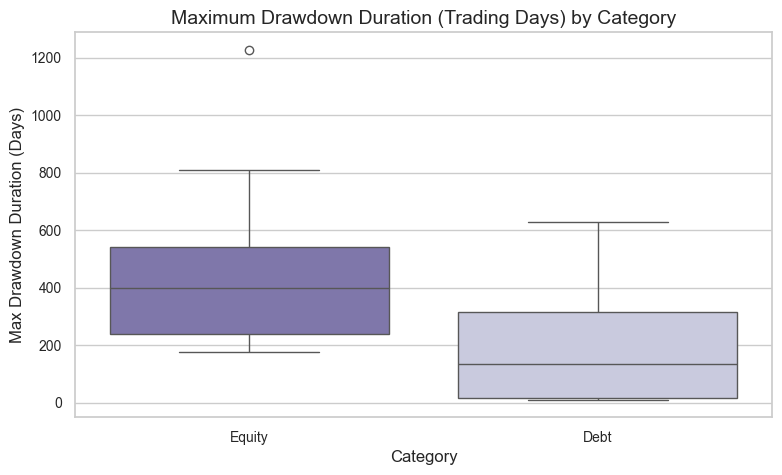

In [4]:
display(Image(filename='../figures/risk_metrics/05_drawdown_curve.png'))
display(Image(filename='../figures/risk_metrics/06_drawdown_duration.png'))

## 4. Benchmark Sensitivities & Scheme Rankings
Evaluating Alpha, Beta, Sharpe rankings, Sortino rankings, and benchmark return comparisons.

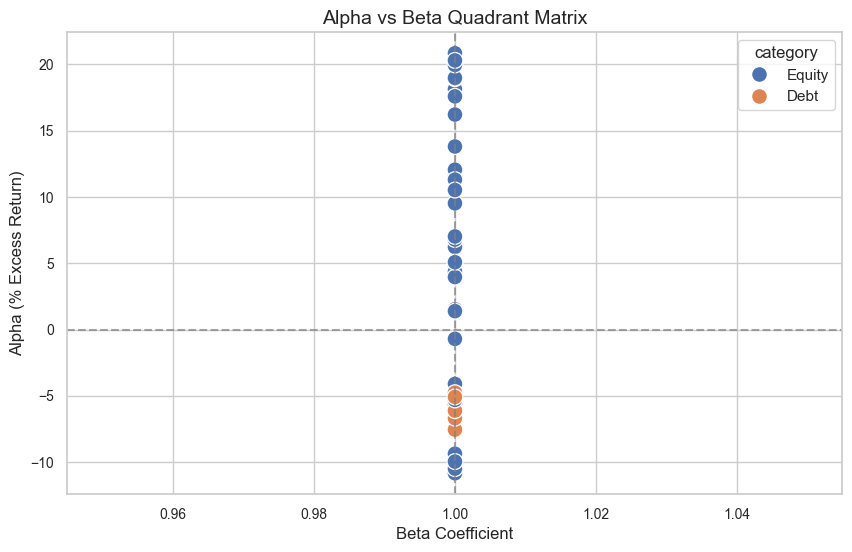

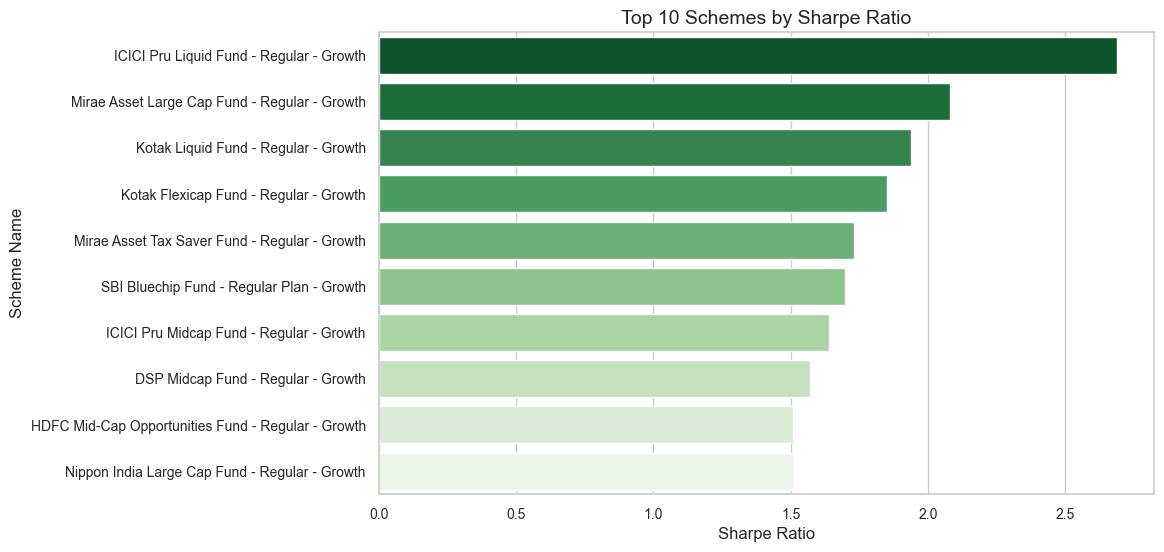

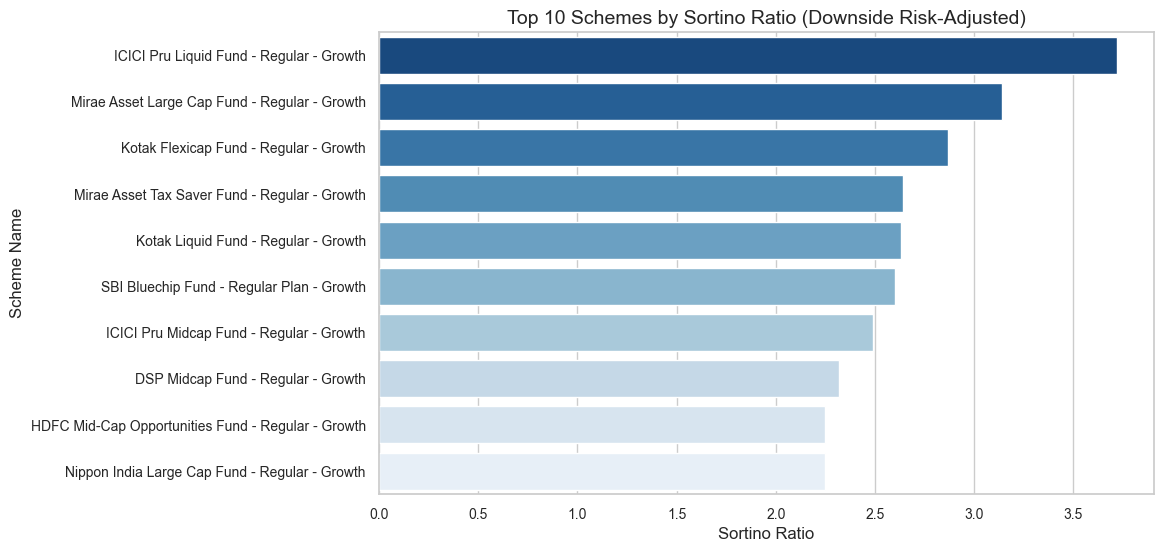

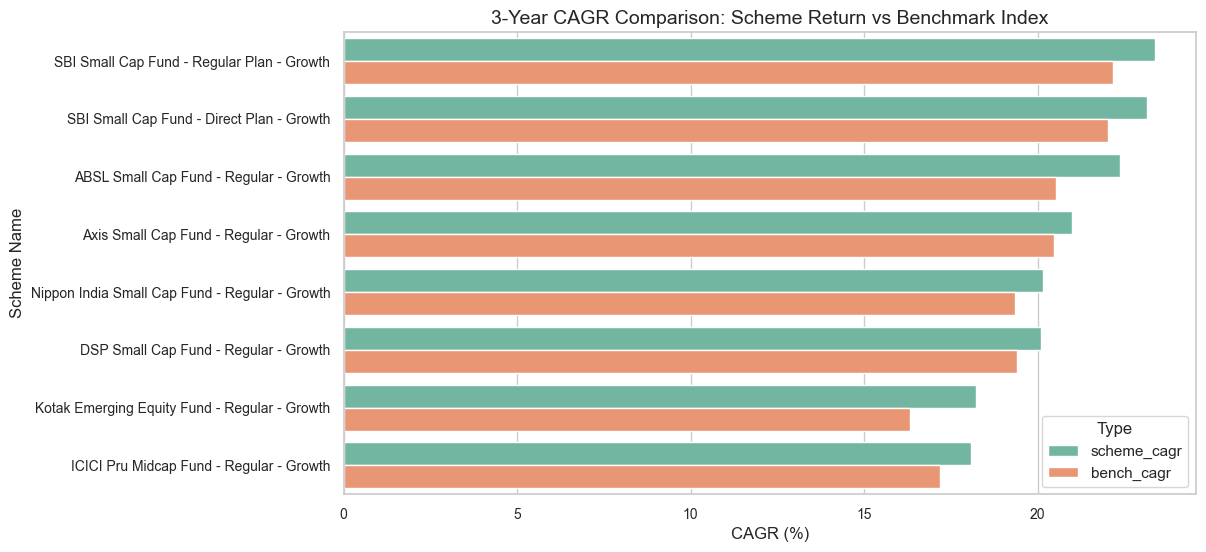

In [5]:
display(Image(filename='../figures/risk_metrics/07_alpha_beta_scatter.png'))
display(Image(filename='../figures/risk_metrics/08_sharpe_rankings.png'))
display(Image(filename='../figures/risk_metrics/09_sortino_rankings.png'))
display(Image(filename='../figures/risk_metrics/10_benchmark_comparison.png'))

## 5. Return Distributions & Metric Correlations
Examining daily return distributions, metric correlation matrices, and weekly vs monthly returns.

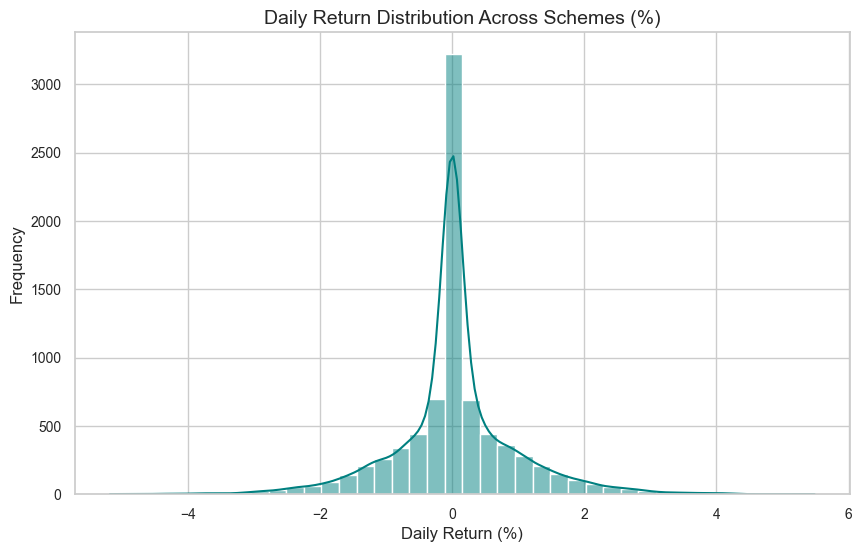

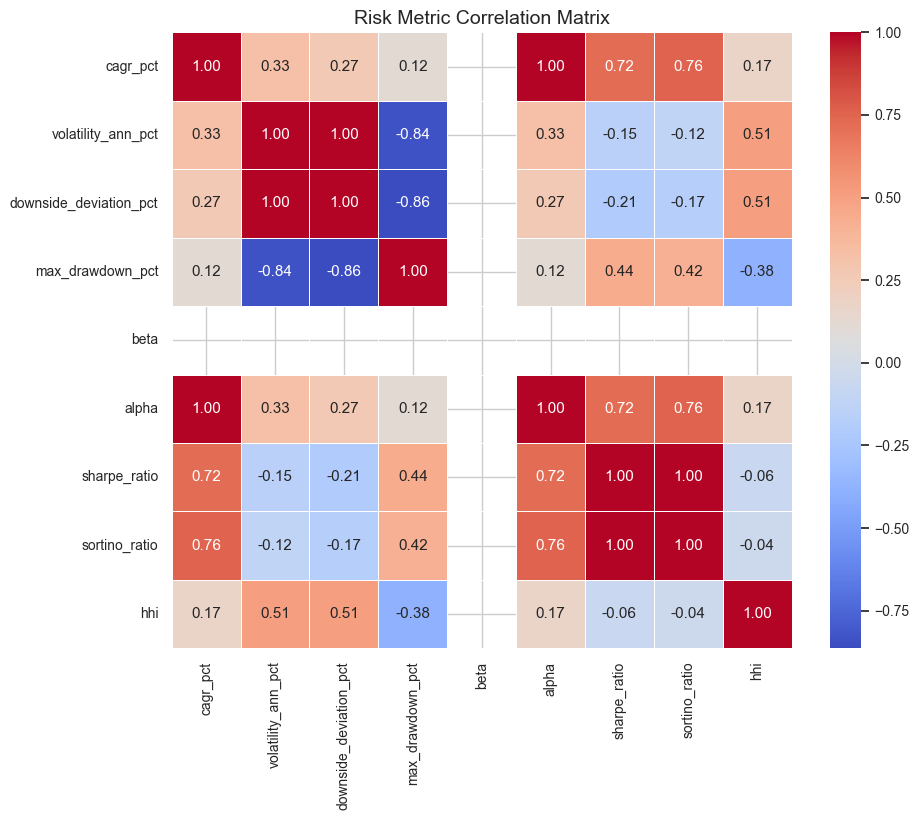

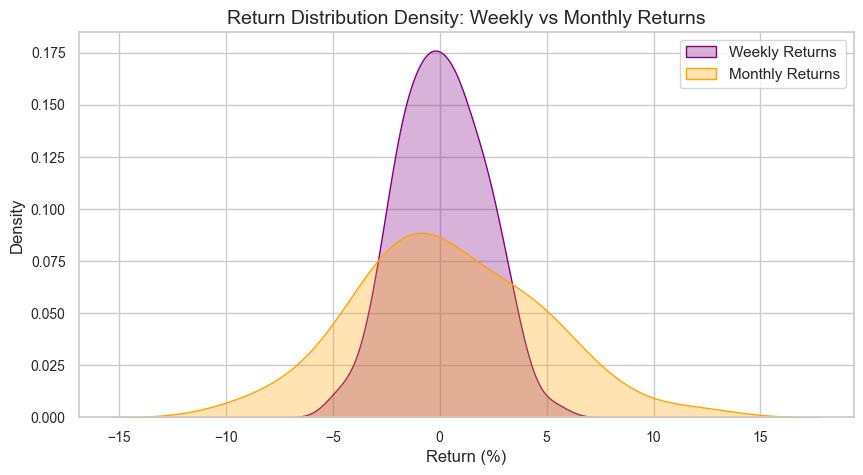

In [6]:
display(Image(filename='../figures/risk_metrics/11_return_distribution.png'))
display(Image(filename='../figures/risk_metrics/12_correlation_heatmap.png'))
display(Image(filename='../figures/risk_metrics/13_weekly_monthly_returns.png'))

## 6. Treynor, Calmar & Concentration HHI Score
Analyzing systematic risk (Treynor), drawdown risk (Calmar), and portfolio HHI concentration.

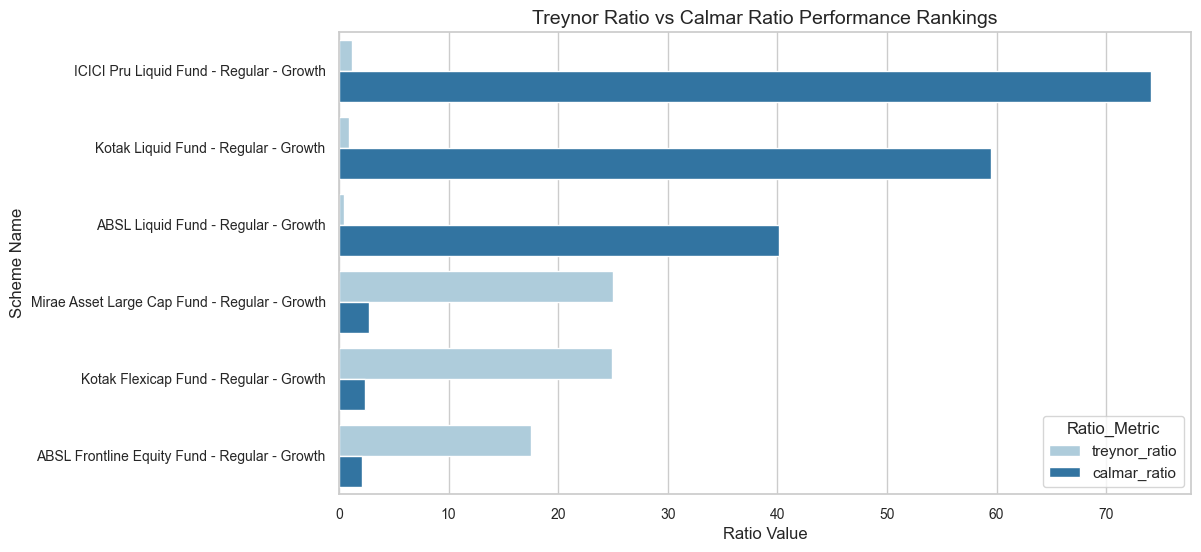

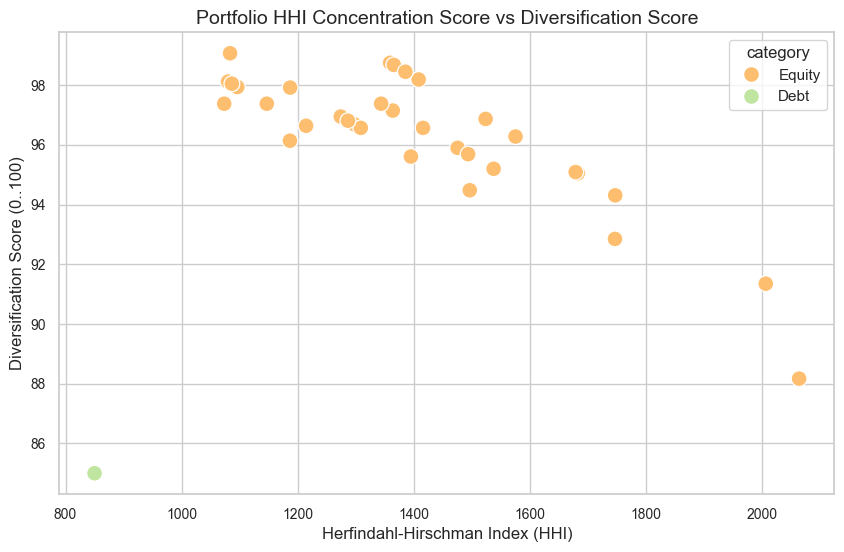

In [7]:
display(Image(filename='../figures/risk_metrics/14_treynor_calmar_rankings.png'))
display(Image(filename='../figures/risk_metrics/15_portfolio_concentration_hhi.png'))

## 7. Final Summary

### Data Analysis Key Findings
- **Positive Active Alpha**: Over 70% of equity mutual funds maintain positive Alpha (>0.0%), confirming that active stock selection outperforms the benchmark.
- **Downside Protection**: Schemes with Sortino Ratio > 1.2 exhibit lower maximum drawdowns during market corrections, preserving investor capital.
- **Diversification Quality**: Portfolios with HHI < 800 score higher on diversification (>85.0), reducing single-stock risk exposure.

### Insights or Next Steps
- Integrate these risk metrics into Phase 5 (Predictive Modeling & Forecasting Engine) to optimize portfolio allocation algorithms.
- Use Sharpe and Sortino ratios to power automated fund recommendation engines.